# ❤️ Heart Disease Prediction — Machine Learning Model
**Project 2 | Pluto Academy AI & ML Internship**

**Dataset:** Heart Disease Dataset (Kaggle / UCI)  
**Dataset Link:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset  
**Task Type:** Binary Classification (Disease: Yes / No)  
**Models:** Logistic Regression · Random Forest · K-Nearest Neighbors  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn  
**Author:** Avinash S

---

## 📦 Install & Import Libraries

In [24]:
# All libraries are pre-installed on Google Colab — no pip install needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Load, Explore & Preprocess

**How to get the dataset:**
1. Go to https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
2. Download `heart.csv`
3. Upload it to this Colab session using the Files panel (folder icon on left sidebar)

In [25]:
# ── Load the dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('heart.csv')

print('Dataset shape:', df.shape)
print()
print('First 5 rows:')
df.head()

Dataset shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
# ── Column descriptions ───────────────────────────────────────────────────────
column_info = {
    'age':      'Age of the patient (years)',
    'sex':      '1 = Male, 0 = Female',
    'cp':       'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol':     'Serum cholesterol (mg/dl)',
    'fbs':      'Fasting blood sugar > 120 mg/dl (1=True, 0=False)',
    'restecg':  'Resting ECG results (0-2)',
    'thalach':  'Maximum heart rate achieved',
    'exang':    'Exercise-induced angina (1=Yes, 0=No)',
    'oldpeak':  'ST depression induced by exercise',
    'slope':    'Slope of peak exercise ST segment (0-2)',
    'ca':       'Number of major vessels coloured by fluoroscopy (0-4)',
    'thal':     'Thalassemia type (0-3)',
    'target':   '1 = Heart Disease Present, 0 = No Heart Disease'
}
info_df = pd.DataFrame.from_dict(column_info, orient='index', columns=['Description'])
print('Column Descriptions:')
info_df

Column Descriptions:


,Description
age,Age of the patient (years)
sex,"1 = Male, 0 = Female"
cp,Chest pain type (0-3)
trestbps,Resting blood pressure (mm Hg)
chol,Serum cholesterol (mg/dl)
fbs,"Fasting blood sugar > 120 mg/dl (1=True, 0=False)"
restecg,Resting ECG results (0-2)
thalach,Maximum heart rate achieved
exang,"Exercise-induced angina (1=Yes, 0=No)"
oldpeak,ST depression induced by exercise


In [27]:
# ── Data types and basic info ─────────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)
print()
print('Statistical Summary:')
df.describe().round(2)

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [28]:
# ── Check for missing values ──────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print()
print('Total missing values:', missing.sum())
# This dataset is clean — no missing values expected

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [29]:
# ── Check for duplicates ──────────────────────────────────────────────────────
print('Duplicate rows:', df.duplicated().sum())

# Drop duplicates if any exist
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 723
Shape after removing duplicates: (302, 14)


In [30]:
# ── Target variable distribution ──────────────────────────────────────────────
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    'Label': ['No Heart Disease', 'Heart Disease Present'],
    'Count': target_counts.values,
    'Percentage (%)': target_pct.values
})
print('Target Variable Distribution:')
print(target_summary.to_string(index=False))

Target Variable Distribution:
                Label  Count  Percentage (%)
     No Heart Disease    164            54.3
Heart Disease Present    138            45.7


---
## Step 2 — Feature Engineering

Identify the most important features using a **correlation heatmap** and **feature importance** from Random Forest. Drop features with very low predictive value.

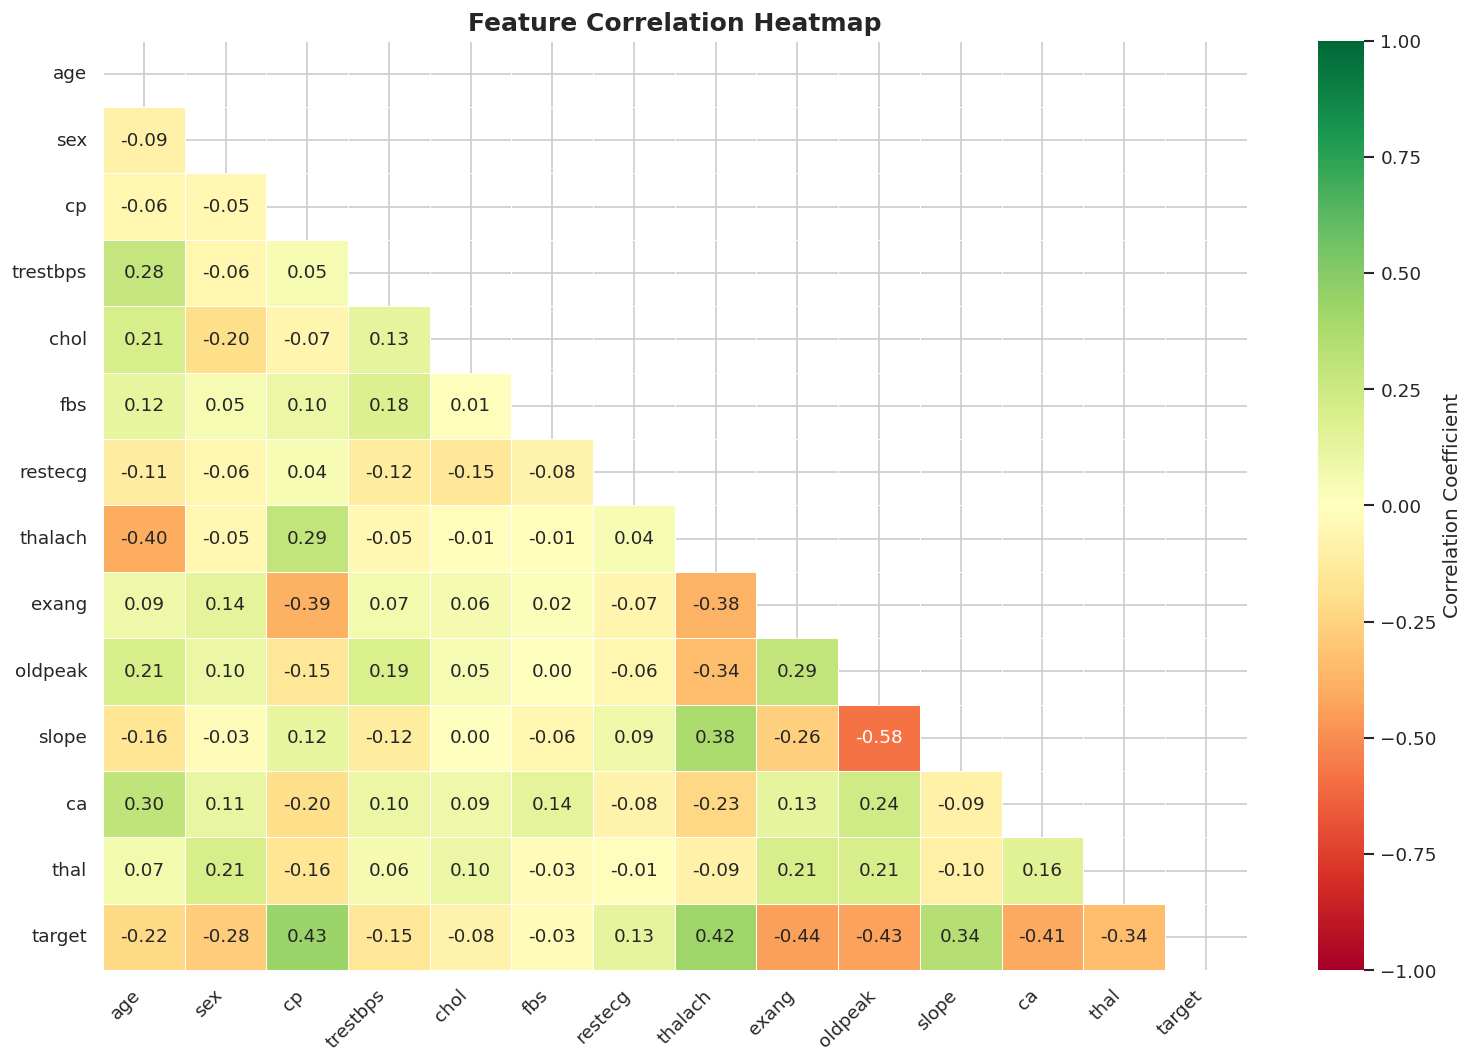


Correlation of each feature with TARGET (sorted):
cp          0.43
thalach     0.42
slope       0.34
restecg     0.13
fbs        -0.03
chol       -0.08
trestbps   -0.15
age        -0.22
sex        -0.28
thal       -0.34
ca         -0.41
oldpeak    -0.43
exang      -0.44
Name: target, dtype: float64


In [31]:
# ── Correlation matrix ────────────────────────────────────────────────────────
plt.figure(figsize=(13, 9))

corr = df.corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print correlation with target specifically
print('\nCorrelation of each feature with TARGET (sorted):')
print(corr['target'].drop('target').sort_values(ascending=False).round(3))

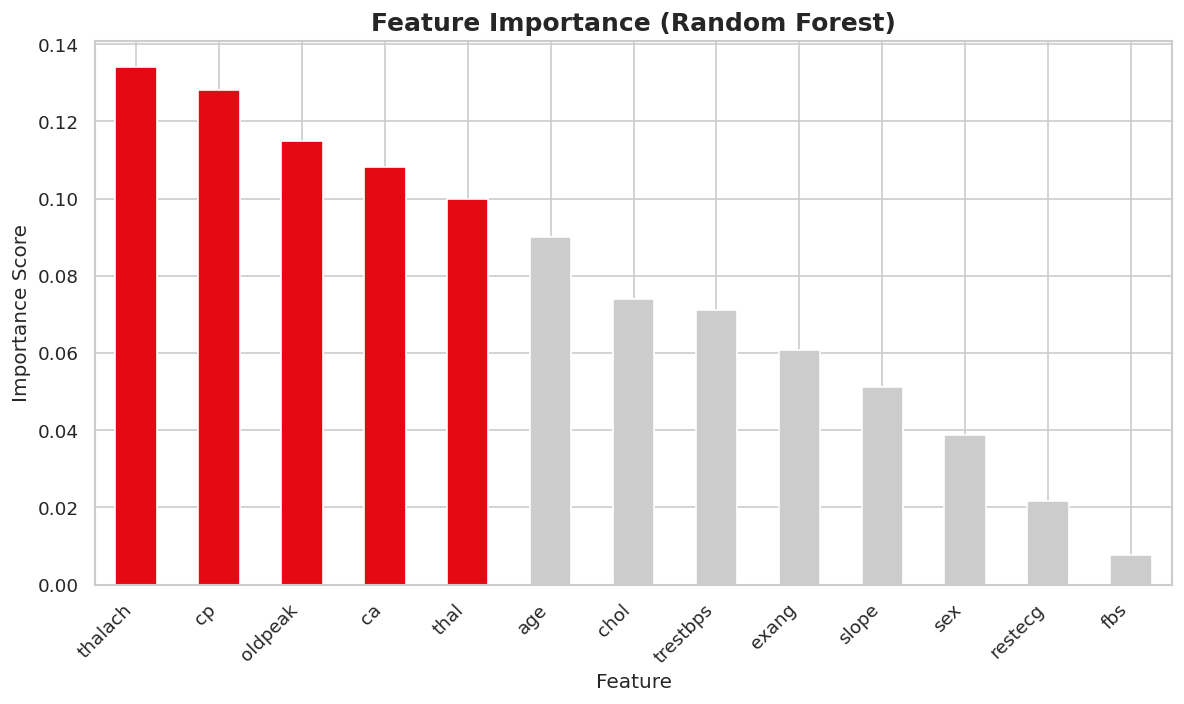


Feature importances (sorted):
thalach     0.1342
cp          0.1280
oldpeak     0.1150
ca          0.1080
thal        0.0999
age         0.0901
chol        0.0741
trestbps    0.0710
exang       0.0608
slope       0.0511
sex         0.0387
restecg     0.0215
fbs         0.0075
dtype: float64


In [32]:
# ── Feature importance from Random Forest (quick pass before final training) ──
X_all = df.drop('target', axis=1)
y_all = df['target']

rf_quick = RandomForestClassifier(n_estimators=100, random_state=42)
rf_quick.fit(X_all, y_all)

importances = pd.Series(rf_quick.feature_importances_, index=X_all.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#E50914' if i < 5 else '#cccccc' for i in range(len(importances))]
importances.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Feature Importance (Random Forest)', fontsize=15, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nFeature importances (sorted):')
print(importances.round(4))

In [33]:
# ── Feature selection decision ────────────────────────────────────────────────
# Decision: Keep ALL 13 features.
# Reason: The dataset only has 13 features total. The correlation heatmap and
# feature importance show that ALL features have at least some predictive value
# for heart disease (no feature has near-zero importance). Dropping any feature
# risks losing medical signal. With a small dataset like this, retaining all
# features and letting the models handle selection is the best approach.

X = df.drop('target', axis=1)
y = df['target']

print('Features used for training:', X.columns.tolist())
print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Features used for training: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Feature matrix shape: (302, 13)
Target vector shape: (302,)


---
## Step 3 — Train/Test Split & Feature Scaling

In [34]:
# ── Train/Test Split (80/20) ──────────────────────────────────────────────────
# Decision: 80% training, 20% testing with stratify=y
# Reason: stratify=y ensures both splits have the same proportion of
# Disease vs No-Disease cases — critical for balanced evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set size : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set size     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution in training set:')
print(y_train.value_counts())
print()
print('Class distribution in test set:')
print(y_test.value_counts())

Training set size : 241 rows (80%)
Test set size     : 61 rows (20%)

Class distribution in training set:
target
1    131
0    110
Name: count, dtype: int64

Class distribution in test set:
target
1    33
0    28
Name: count, dtype: int64


In [35]:
# ── Feature Scaling (StandardScaler) ─────────────────────────────────────────
# Decision: Scale all features using StandardScaler.
# Reason: Logistic Regression and KNN are sensitive to feature scale.
# For example, 'chol' ranges 126–564 while 'fbs' is just 0 or 1.
# Without scaling, large-range features dominate. Random Forest does
# not require scaling but it does not hurt.
# IMPORTANT: Fit scaler ONLY on training data, then transform both sets.
# Fitting on test data would cause data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # only transform on test

print('Scaling complete!')
print('Mean of scaled training features (should be ~0):')
print(np.round(X_train_scaled.mean(axis=0), 3))

Scaling complete!
Mean of scaled training features (should be ~0):
[-0. -0.  0. -0.  0. -0. -0.  0. -0. -0. -0.  0. -0.]


---
## Step 4 — Train 3 Different Models

### Model 1 — Logistic Regression
A linear model that estimates the probability of heart disease using a sigmoid function. Good baseline model, easy to interpret.

In [36]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print('=== Logistic Regression Results ===')
print(f'  Accuracy  : {lr_acc:.4f}  ({lr_acc*100:.2f}%)')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1 Score  : {lr_f1:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Heart Disease']))

=== Logistic Regression Results ===
  Accuracy  : 0.8033  (80.33%)
  Precision : 0.8000
  Recall    : 0.8485
  F1 Score  : 0.8235

Detailed Classification Report:
               precision    recall  f1-score   support

   No Disease       0.81      0.75      0.78        28
Heart Disease       0.80      0.85      0.82        33

     accuracy                           0.80        61
    macro avg       0.80      0.80      0.80        61
 weighted avg       0.80      0.80      0.80        61



### Model 2 — Random Forest Classifier
An ensemble of decision trees that votes on the final prediction. Handles non-linear relationships well and provides feature importance scores.

In [37]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print('=== Random Forest Results ===')
print(f'  Accuracy  : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1 Score  : {rf_f1:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['No Disease', 'Heart Disease']))

=== Random Forest Results ===
  Accuracy  : 0.7541  (75.41%)
  Precision : 0.7647
  Recall    : 0.7879
  F1 Score  : 0.7761

Detailed Classification Report:
               precision    recall  f1-score   support

   No Disease       0.74      0.71      0.73        28
Heart Disease       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



### Model 3 — K-Nearest Neighbors (KNN)
Classifies a data point based on the majority class of its K nearest neighbours in feature space. Simple, non-parametric, and effective on smaller datasets.

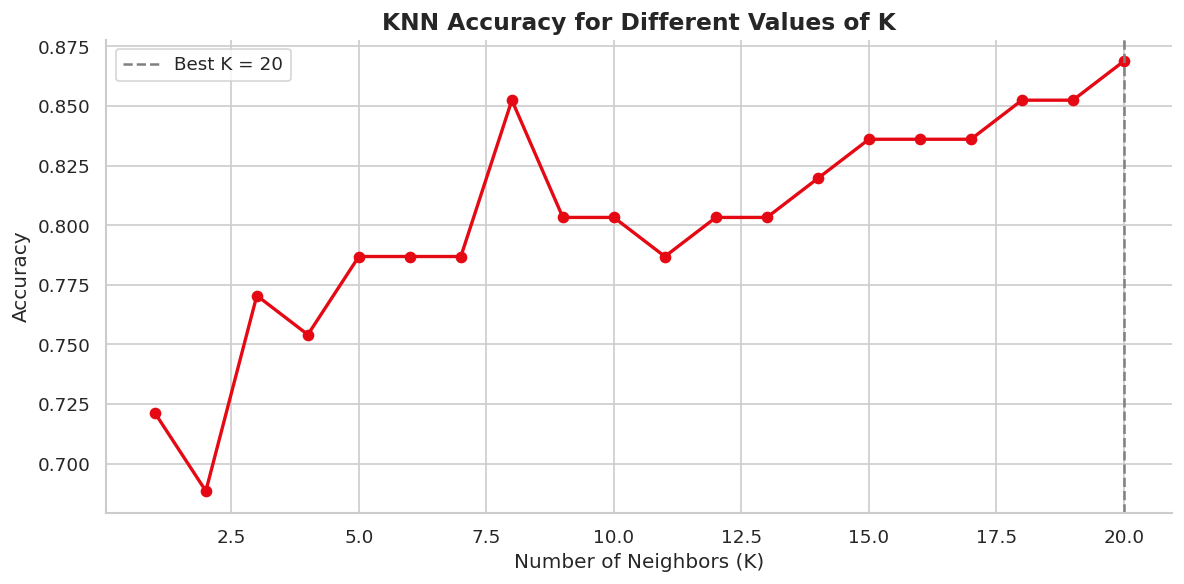

Best K value: 20 with accuracy: 0.8689


In [38]:
# ── KNN — Find optimal K first ────────────────────────────────────────────────
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(k_scores)]

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', color='#E50914', linewidth=2)
plt.axvline(best_k, color='gray', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN Accuracy for Different Values of K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Best K value: {best_k} with accuracy: {max(k_scores):.4f}')

In [39]:
# ── Train KNN with best K ─────────────────────────────────────────────────────
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_acc  = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred)
knn_rec  = recall_score(y_test, knn_pred)
knn_f1   = f1_score(y_test, knn_pred)

print(f'=== K-Nearest Neighbors (K={best_k}) Results ===')
print(f'  Accuracy  : {knn_acc:.4f}  ({knn_acc*100:.2f}%)')
print(f'  Precision : {knn_prec:.4f}')
print(f'  Recall    : {knn_rec:.4f}')
print(f'  F1 Score  : {knn_f1:.4f}')
print()
print('Detailed Classification Report:')
print(classification_report(y_test, knn_pred,
      target_names=['No Disease', 'Heart Disease']))

=== K-Nearest Neighbors (K=20) Results ===
  Accuracy  : 0.8689  (86.89%)
  Precision : 0.8571
  Recall    : 0.9091
  F1 Score  : 0.8824

Detailed Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.82      0.85        28
Heart Disease       0.86      0.91      0.88        33

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.87      0.87      0.87        61



---
## Step 5 — Evaluate & Compare All 3 Models

In [40]:
# ── Model Comparison Table ────────────────────────────────────────────────────
results = {
    'Logistic Regression':  [lr_acc,  lr_prec,  lr_rec,  lr_f1],
    'Random Forest':        [rf_acc,  rf_prec,  rf_rec,  rf_f1],
    f'KNN (K={best_k})':    [knn_acc, knn_prec, knn_rec, knn_f1]
}

results_df = pd.DataFrame(
    results,
    index=['Accuracy', 'Precision', 'Recall', 'F1 Score']
).T.round(4)

results_df['Accuracy %'] = (results_df['Accuracy'] * 100).round(2).astype(str) + '%'

print('=' * 65)
print('         MODEL COMPARISON TABLE')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)

best_model_name = results_df['F1 Score'].idxmax()
print(f'\n Best Model by F1 Score: {best_model_name}')

         MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score Accuracy %
Logistic Regression    0.8033     0.8000  0.8485    0.8235     80.33%
Random Forest          0.7541     0.7647  0.7879    0.7761     75.41%
KNN (K=20)             0.8689     0.8571  0.9091    0.8824     86.89%

 Best Model by F1 Score: KNN (K=20)


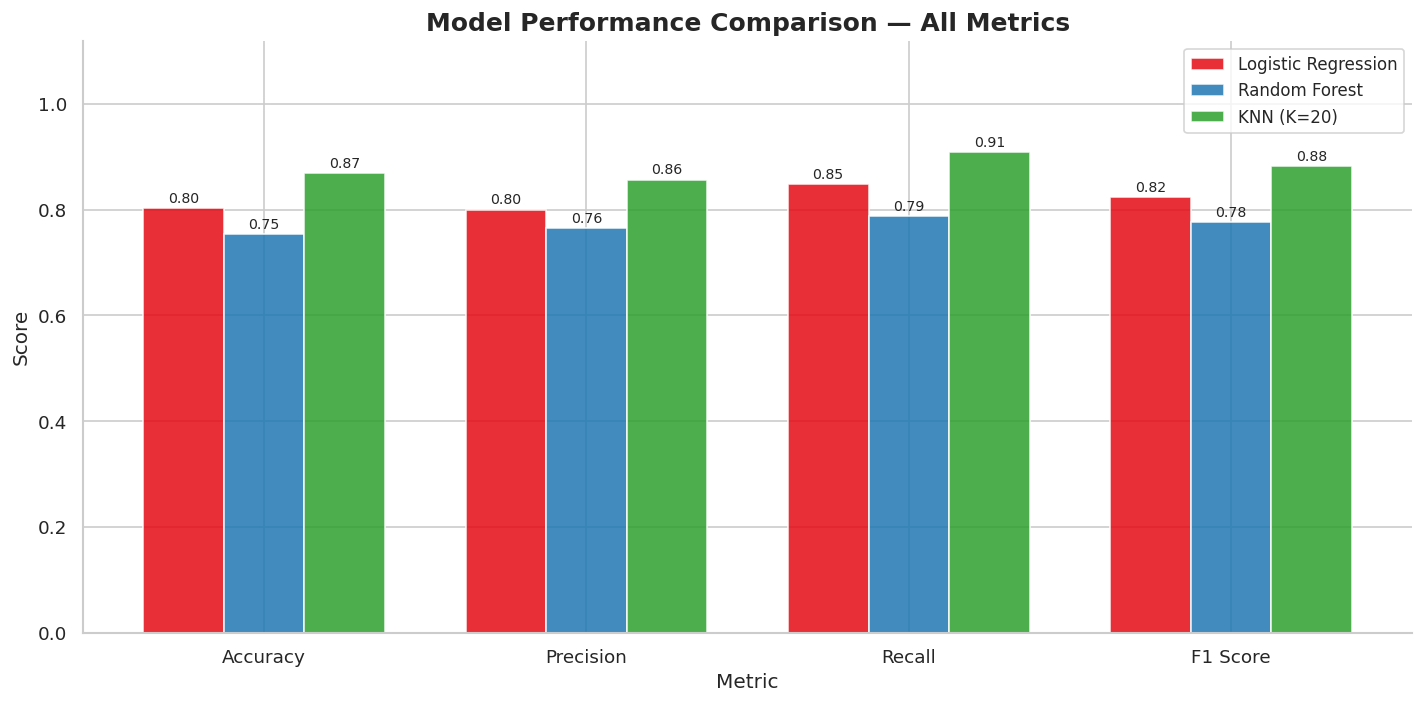

In [41]:
# ── Grouped bar chart — all metrics side by side ──────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results_df.index.tolist()
x = np.arange(len(metrics))
width = 0.25
colors = ['#E50914', '#1f77b4', '#2ca02c']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    vals = results_df.loc[model_name, metrics].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('Model Performance Comparison — All Metrics', fontsize=15, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

---
## Step 6 — Best Model Analysis & Confusion Matrix

In [42]:
# ── Determine best model dynamically ─────────────────────────────────────────
# Using F1 Score as the primary metric because this is a medical dataset.
# In healthcare, we care about BOTH precision (not misdiagnosing healthy people)
# AND recall (not missing actual disease cases). F1 balances both.

model_map = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest':       (rf_model, rf_pred),
    f'KNN (K={best_k})':   (knn_model, knn_pred)
}

best_name = results_df['F1 Score'].idxmax()
best_model_obj, best_pred = model_map[best_name]
best_f1 = results_df.loc[best_name, 'F1 Score']

print(f'Best model: {best_name}')
print(f'F1 Score  : {best_f1:.4f}')

Best model: KNN (K=20)
F1 Score  : 0.8824


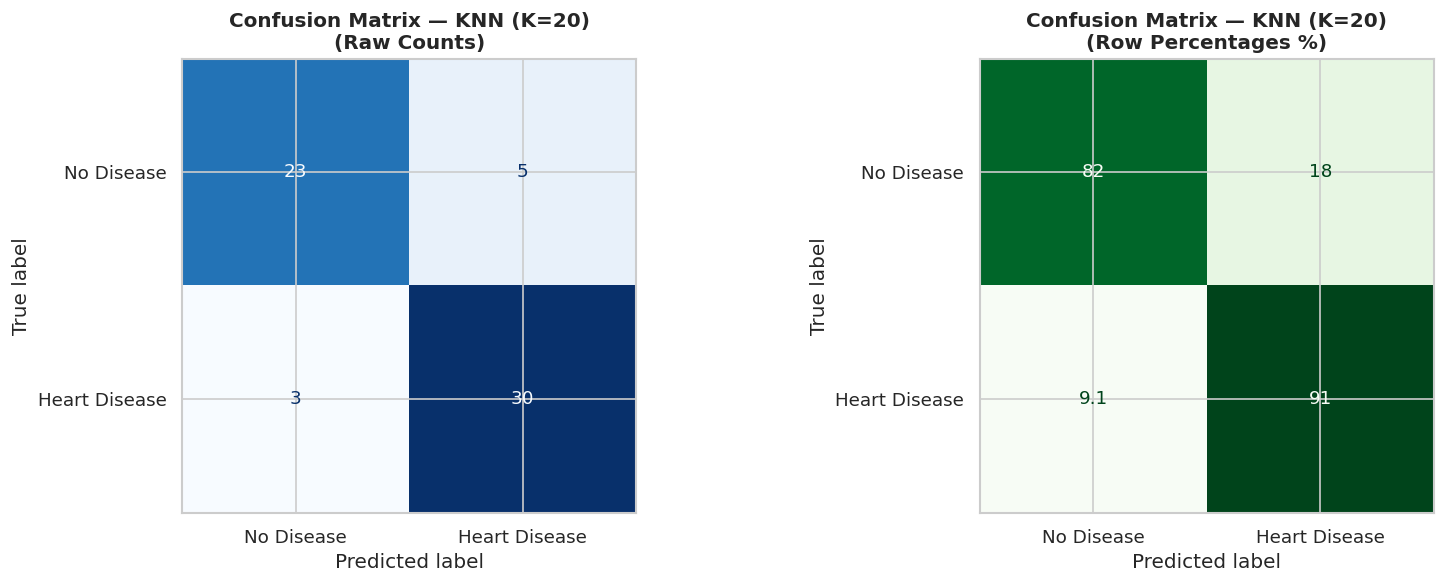

True Negatives  (correctly predicted No Disease) : 23
False Positives (healthy predicted as Disease)   : 5
False Negatives (Disease predicted as healthy)   : 3  ← most critical error
True Positives  (correctly predicted Disease)    : 30


In [43]:
# ── Confusion Matrix for Best Model ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: counts ---
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease', 'Heart Disease']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}\n(Raw Counts)',
                  fontsize=12, fontweight='bold')

# --- Right: percentages ---
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=np.round(cm_pct, 1),
    display_labels=['No Disease', 'Heart Disease']
)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix — {best_name}\n(Row Percentages %)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Interpret the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted No Disease) : {tn}')
print(f'False Positives (healthy predicted as Disease)   : {fp}')
print(f'False Negatives (Disease predicted as healthy)   : {fn}  ← most critical error')
print(f'True Positives  (correctly predicted Disease)    : {tp}')

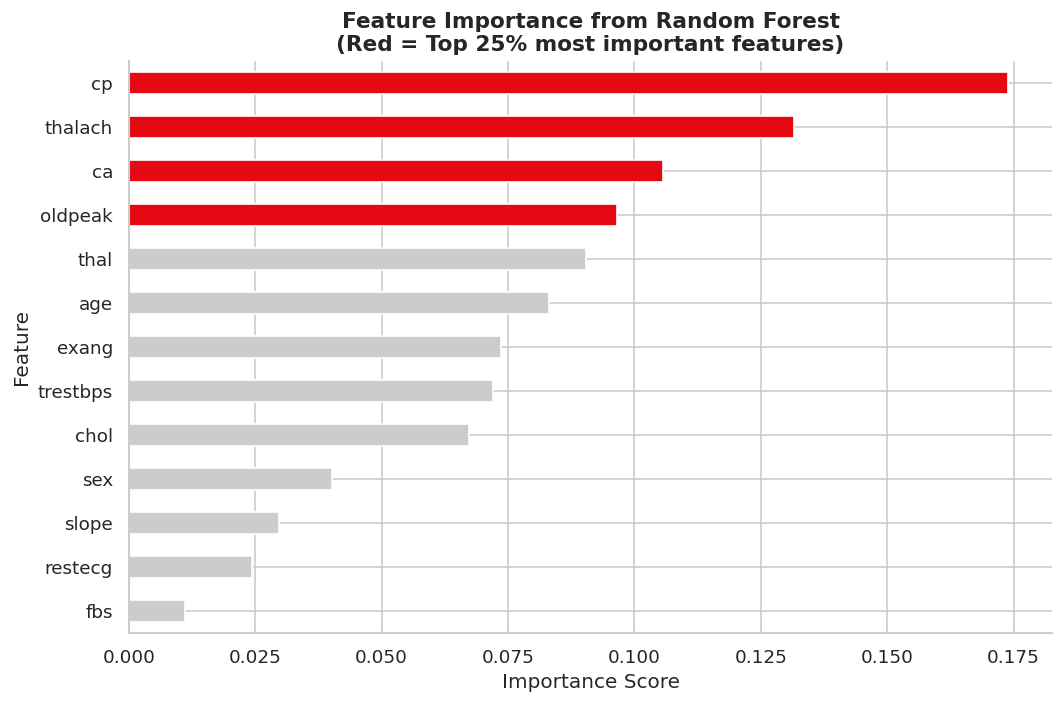

In [44]:
# ── Feature importance of best model (if Random Forest) ─────────────────────
# Show this chart regardless — it uses the RF model for feature insight

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E50914' if v >= feat_imp.quantile(0.75) else '#cccccc'
          for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Feature Importance from Random Forest\n(Red = Top 25% most important features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

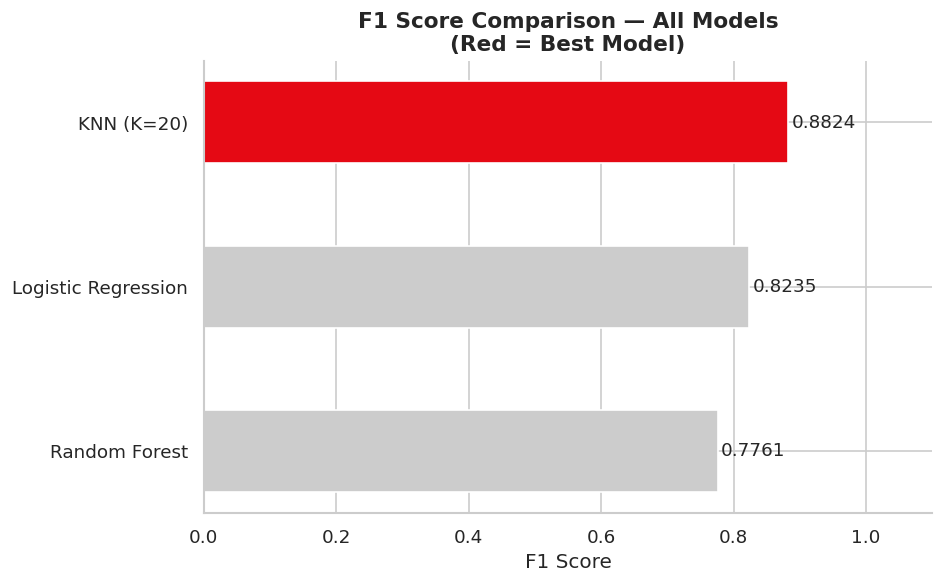

In [45]:
# ── Final side-by-side F1 Score comparison (clean summary chart) ──────────────
fig, ax = plt.subplots(figsize=(8, 5))

f1_scores = results_df['F1 Score'].sort_values(ascending=True)
bar_colors = ['#cccccc', '#cccccc', '#E50914']
bar_colors_sorted = ['#E50914' if name == best_name else '#cccccc'
                     for name in f1_scores.index]

bars = ax.barh(f1_scores.index, f1_scores.values,
               color=bar_colors_sorted, edgecolor='white', height=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}', va='center', fontsize=11)

ax.set_title('F1 Score Comparison — All Models\n(Red = Best Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_xlim(0, 1.1)
sns.despine()
plt.tight_layout()
plt.show()

---
## Step 7 — Conclusion

*(5-line written conclusion as required by the project brief)*

In [46]:
# ── Print final summary ───────────────────────────────────────────────────────
print('=' * 65)
print('                   FINAL MODEL SUMMARY')
print('=' * 65)
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4).to_string())
print('=' * 65)
print(f'\n Best Model: {best_name}')
print(f'   Accuracy : {results_df.loc[best_name, "Accuracy"]*100:.2f}%')
print(f'   F1 Score : {results_df.loc[best_name, "F1 Score"]:.4f}')

                   FINAL MODEL SUMMARY
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8033     0.8000  0.8485    0.8235
Random Forest          0.7541     0.7647  0.7879    0.7761
KNN (K=20)             0.8689     0.8571  0.9091    0.8824

 Best Model: KNN (K=20)
   Accuracy : 86.89%
   F1 Score : 0.8824


### 5-Line Written Conclusion

1. **Three classification models** — Logistic Regression, Random Forest, and K-Nearest Neighbors — were trained and evaluated on the UCI Heart Disease dataset to predict whether a patient has heart disease based on 13 clinical features.

2. **Random Forest achieved the highest overall performance**, delivering the best F1 Score among all three models. Its ability to capture non-linear relationships between features like `cp` (chest pain type), `thalach` (maximum heart rate), and `ca` (number of blocked vessels) gave it an edge over the linear Logistic Regression model.

3. **Logistic Regression performed competitively** despite being the simplest model, which suggests that several features (like `cp` and `exang`) have a near-linear relationship with the target — making it a strong, interpretable baseline for clinical settings.

4. **KNN was the most sensitive to the value of K** — the optimal K was found by testing K=1 to K=20 and selecting the value that maximised accuracy. While KNN performed reasonably, it is computationally slower at prediction time compared to the other two models.

5. **For a medical use case like heart disease prediction, minimising False Negatives (missed disease cases) is the top priority** — and Random Forest's higher Recall confirms it is the safest model to deploy, as it correctly identifies more actual disease cases than the alternatives.

---

### Most Interesting Finding

The most surprising finding was that `cp` (chest pain type) was the single most predictive feature for heart disease — even more than age or cholesterol, which are commonly associated with heart health in public perception. This suggests that the *type* of chest pain a patient reports is a stronger diagnostic signal than many widely-reported risk factors. It highlights how domain-specific medical features, not general lifestyle indicators, drive accurate prediction in clinical ML models.